In [5]:
import pandas as pd

filenames = [
    "processed_comments_kien.csv",
    "processed_comments_thai.csv",
    "processed_comments_vu.csv"
]


with open("processed_merge.csv", "w", encoding="utf-8") as fout:
    for file in filenames:
        with open(file, "r", encoding="utf-8") as fin:
            for line in fin:
                fout.write(line)
             
print("Tạo file merge thành công")       



Tạo file merge thành công


In [6]:
import csv

input_file = 'processed_merge.csv'
output_file = 'processed_merge_format.csv'

with open(input_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

processed_rows = []

for line in lines:
    line = line.strip()
    if not line:
        continue
    
    # 1. Tìm dấu phẩy cuối cùng (phân tách giữa comment và label_id)
    # Chúng ta tìm từ phải sang trái để tránh nhầm với dấu phẩy trong nội dung
    last_comma_pos = line.rfind(',')
    
    if last_comma_pos != -1:
        comment = line[:last_comma_pos]    # Phần nội dung
        label_id = line[last_comma_pos+1:] # Phần số (0 hoặc -1)
        
        # 2. Xử lý phần comment:
        # - Thay thế '\,' thành ','
        # - Loại bỏ các dấu ngoặc kép thừa nếu có trước đó
        clean_comment = comment.replace('\\,', ',').strip('"')
        
        processed_rows.append([clean_comment, label_id])

# 3. Ghi ra file mới với định dạng chuẩn
with open(output_file, 'w', encoding='utf-8-sig', newline='') as f:
    # QUOTE_MINIMAL sẽ tự động bọc "" nếu nội dung có dấu phẩy
    # Hoặc dùng QUOTE_NONNUMERIC để bọc tất cả các cột chữ
    writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
    
    # Ghi header nếu file cũ có header (giả sử dòng đầu là comment,label_id)
    writer.writerows(processed_rows)

print(f"Đã chuyển đổi thành công! Kiểm tra file: {output_file}")

Đã chuyển đổi thành công! Kiểm tra file: processed_merge_format.csv


In [8]:
import pandas as pd

# 1. Đọc file đã chuẩn hóa
df = pd.read_csv("./groupdata_clean/final_merge_dataset_by_group.csv")


df = df[df['label_id'] != -1].copy()
# 2. Thống kê số lượng từng loại nhãn
label_counts = df['label_id'].value_counts()

# 3. Tính tỷ lệ phần trăm cho từng loại nhãn
label_percentage = df['label_id'].value_counts(normalize=True) * 100

# 4. In kết quả dạng bảng
print("--- THỐNG KÊ NHÃN ---")
summary = pd.DataFrame({
    'Số lượng': label_counts,
    'Tỷ lệ (%)': label_percentage
})
print(summary)

# 5. Kiểm tra xem có giá trị null nào không
print("\nSố lượng dòng bị trống nhãn:", df['label_id'].isnull().sum())

--- THỐNG KÊ NHÃN ---
          Số lượng  Tỷ lệ (%)
label_id                     
2            10491  50.261103
0             5911  28.318881
1             4471  21.420016

Số lượng dòng bị trống nhãn: 0


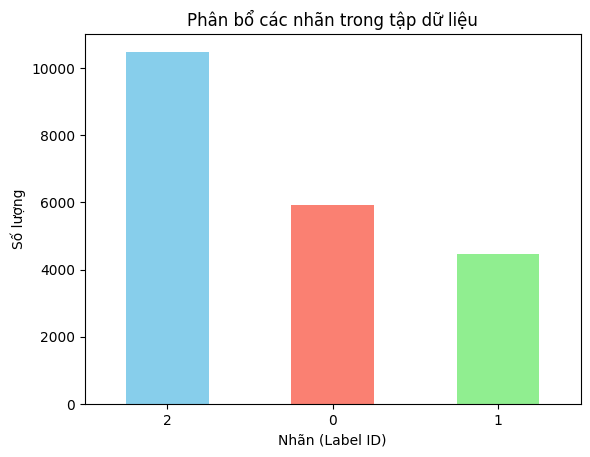

In [6]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ cột
label_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Phân bổ các nhãn trong tập dữ liệu')
plt.xlabel('Nhãn (Label ID)')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.show()

In [13]:
import pandas as pd
import re
import unicodedata
from pyvi import ViTokenizer

# --- DICTIONARIES ---
# Bạn có thể mở rộng danh sách này hoặc đọc từ file .txt
teencode_dict = {
    "đc": "được", "ko": "không", "k": "không", "kh": "không",
    "vcl": "vô cùng luôn", "vkl": "vô cùng luôn", "dcm": "địt con mẹ",
    "đm": "địt mẹ", "cc": "con cặc", "th": "thế", "n": "nó", "m": "mày",
    "t": "tao", "j": "gì", "bt": "bình thường", "v": "vậy"
}

# Danh sách stopword cơ bản (nên dùng file vietnamese-stopwords.txt chuẩn)
stopwords = ["và", "của", "là", "có", "trong", "đã", "cho", "rằng"] 

# --- FUNCTIONS ---

def normalize_unicode(text):
    """Chuẩn hóa Unicode về dạng NFC (UTF-8)"""
    return unicodedata.normalize('NFC', text)

def remove_links(text):
    """Xóa các đường link http/https/www"""
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_redundant_spaces(text):
    """Xóa khoảng trắng thừa"""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_redundant_chars(text):
    """Xóa ký tự lặp lại liên tiếp (ví dụ: haaaaa -> ha)"""
    return re.sub(r'(.)\1{2,}', r'\1', text)

def normalize_accents(text):
    """
    Chuẩn hóa đặt dấu tiếng Việt (Dựa trên quy tắc bạn cung cấp)
    Lưu ý: Thư viện 'underthesea' hoặc 'pyvi' có tích hợp sẵn, 
    nhưng đây là hàm logic mô phỏng quy tắc bạn yêu cầu.
    """
    # Trong thực tế, nên dùng thư viện chuyên dụng để xử lý các case phức tạp:
    # return underthesea.text_normalize(text)
    return text # Tạm thời giữ nguyên vì đa số bộ gõ hiện nay đã chuẩn hóa NFC

def deteen_code(text, dictionary):
    """Chuyển đổi teencode sang từ gốc"""
    words = text.split()
    converted_words = [dictionary.get(w, w) for w in words]
    return " ".join(converted_words)

def preprocess_pipeline(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Xóa Links
    text = remove_links(text)
    
    # 3. Chuẩn hóa Unicode & Dấu
    text = normalize_unicode(text)
    text = normalize_accents(text)
    
    # 4. Xóa ký tự lặp (ví dụ: "vclll" -> "vcl")
    text = remove_redundant_chars(text)
    
    # 5. Xóa khoảng trắng thừa
    text = remove_redundant_spaces(text)
    
    # 6. Word Tokenize (Dùng ViTokenizer của PyVi)
    # Kết quả: "viện trưởng" -> "viện_trưởng"
    text = ViTokenizer.tokenize(text)
    
    # 7. De-teencode
    text = deteen_code(text, teencode_dict)
    
    # 8. Remove Stopwords
    words = text.split()
    words = [w for w in words if w.replace("_", " ") not in stopwords]
    
    return " ".join(words)

# --- MAIN EXECUTION ---

def process_file(file_path, output_path):
    print(f"Processing: {file_path}...")
    df = pd.read_csv(file_path)
    
    # Áp dụng hàm tiền xử lý cho cột free_text
    df['clean_text'] = df['text'].apply(preprocess_pipeline)
    
    # Lưu kết quả (giữ lại nhãn label_id)
    df[['clean_text', 'label_id']].to_csv(output_path, index=False, encoding='utf-8')
    print(f"Saved to: {output_path}")

# Danh sách các file cần xử lý
files = {
    "./groupdata_clean/final_merge_dataset_by_group.csv":  "./groupdata_clean/final_merge_dataset_by_group_cleaned.csv"
}

for inp, out in files.items():
    try:
        process_file(inp, out)
    except FileNotFoundError:
        print(f"Không tìm thấy file {inp}, bỏ qua...")

print("Hoàn thành tiền xử lý!")

Processing: ./groupdata_clean/final_merge_dataset_by_group.csv...
Saved to: ./groupdata_clean/final_merge_dataset_by_group_cleaned.csv
Hoàn thành tiền xử lý!


In [16]:
import pandas as pd

df = pd.read_csv("./groupdata_clean/final_merge_dataset_by_group_cleaned.csv")

value_count = df['label_id'].value_counts()
value_count_percentage = df['label_id'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Số lượng" : value_count,
    "Tỉ lệ": value_count_percentage
})

print(summary)

          Số lượng      Tỉ lệ
label_id                     
2            10491  50.261103
0             5911  28.318881
1             4471  21.420016
